In [1]:
import pandas as pd
import ftplib
import io
import requests
import os
from datetime import datetime, timedelta, timezone
from dateutil.relativedelta import relativedelta
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
def open_daily_csv(station_file_path,
                    ftp_gen_path='anon/gen/clim_data/IDCKWCDEA0/tables',
                    ftp_host='ftp.bom.gov.au',ftp_user='',ftp_pass='',file_encoding='latin1'):
    ftp_file_path = f'{ftp_gen_path}/{station_file_path}'
    try:
        with ftplib.FTP(ftp_host) as ftp:
            ftp.login(user=ftp_user, passwd=ftp_pass)
    
            # Create an in-memory binary stream to store the file content
            r = io.BytesIO()
            ftp.retrbinary(f'RETR {ftp_file_path}', r.write)
            r.seek(0)  # Rewind the stream to the beginning
    
            # Read the CSV using pandas, specifying the correct encoding
            df = pd.read_csv(r, skiprows=0,header=[7,8,9,10],encoding=file_encoding)
            new_headers=[]
            for i in range(len(df.columns)):
                original_list=list(df.columns[i])
                substring_to_remove = "Unnamed: "
                new_list = [item for item in original_list if substring_to_remove not in item]
                #substring_to_remove = "Copyright "
                #new_list = [item for item in new_list if substring_to_remove not in item]
                new_headers.append(" ".join(new_list))
            df.columns=new_headers
    
    except ftplib.all_errors as e:
        print(f"FTP error: {e}")
    except UnicodeDecodeError as e:
        print(f"Encoding error: {e}")
        print(f"Try a different encoding, e.g., 'iso-8859-1' or 'windows-1252'.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

    return df

In [17]:
################################################################################################################################
################################################################################################################################
###############################################################################################################################
stations = pd.read_csv('station_list_airports.csv')
start_date=datetime.now(timezone.utc) + relativedelta(hours=10)
ydt=start_date-relativedelta(days=2)
yesterday_obs=[]
for index,row in stations.iterrows():
    station_file_path=f"{row.State.lower()}/{row['Daily Name']}/{row['Daily Name']}-{ydt.strftime('%Y%m')}.csv"
    df=open_daily_csv(station_file_path)
    df_temp=df[df.Date==ydt.strftime('%d/%m/%Y')].reset_index(drop=True)
    df_temp['State']=[row.State]
    
    yesterday_obs.append(df_temp)
yesterday_obs=pd.concat(yesterday_obs, ignore_index=True).reset_index(drop=True)

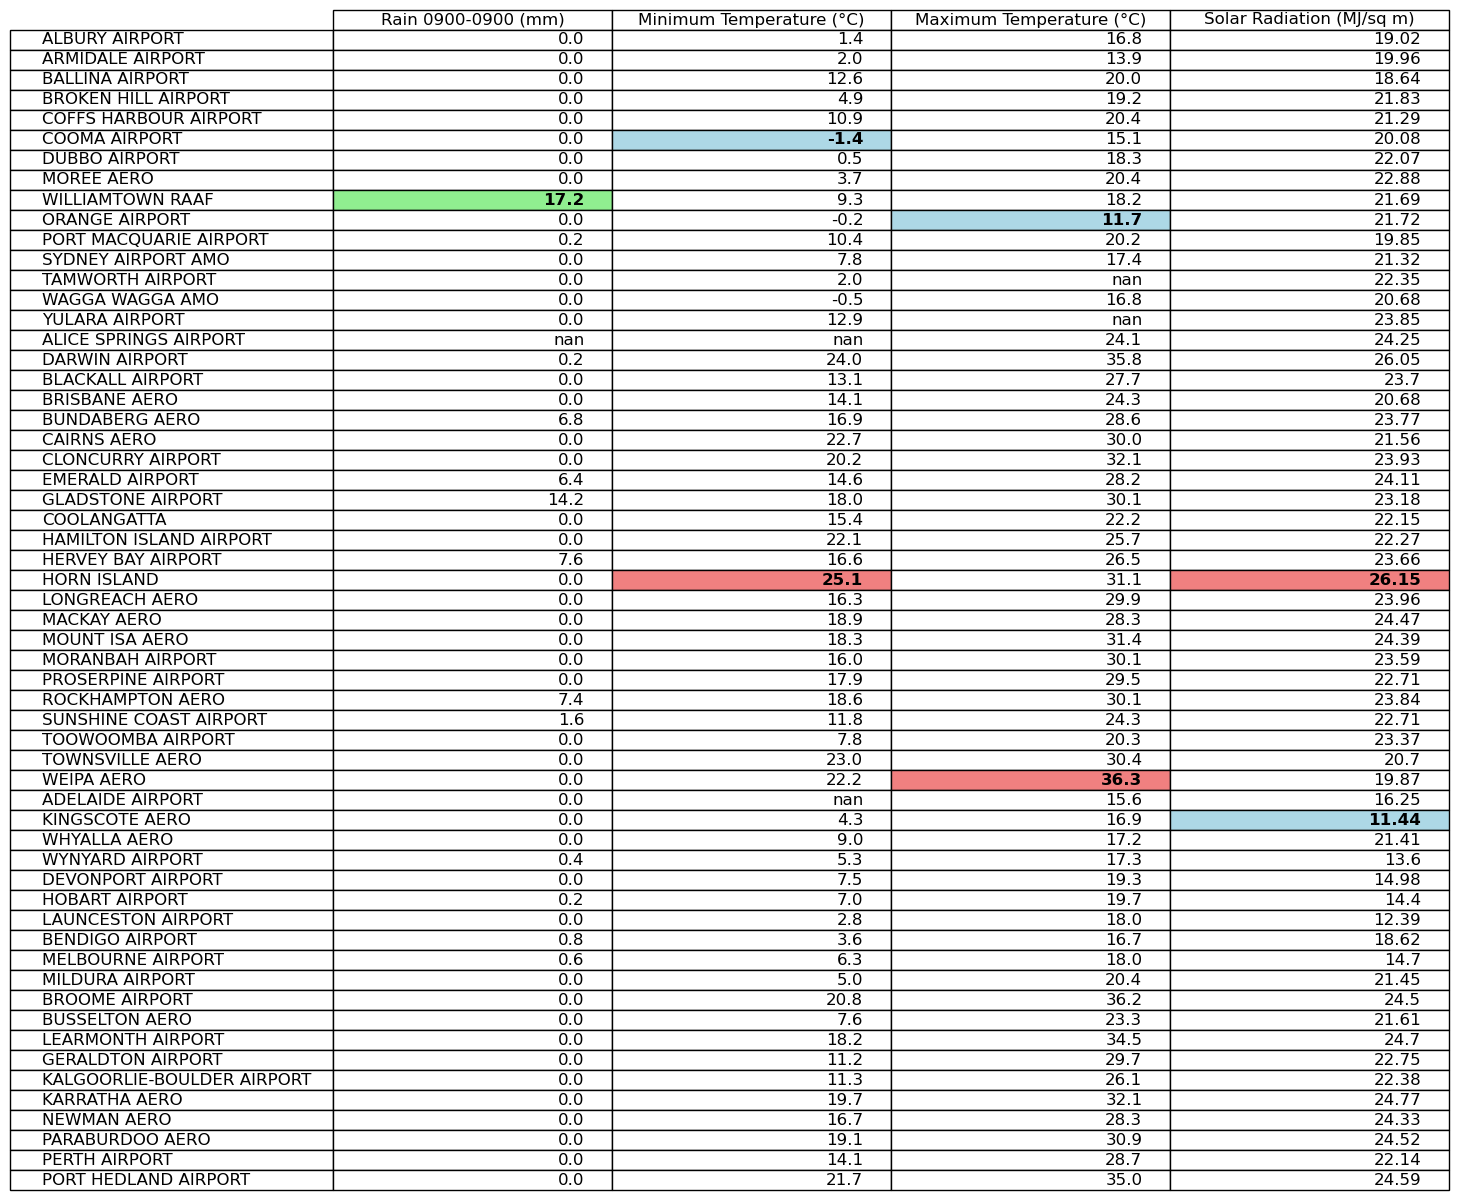

In [19]:
# 1. Create the DataFrame
weather_df = yesterday_obs[["Station Name","Rain 0900-0900 (mm)","Minimum Temperature (°C)","Maximum Temperature (°C)","Solar Radiation (MJ/sq m)"]].set_index('Station Name')

for col in weather_df.columns:
    weather_df[col]=pd.to_numeric(weather_df[col], errors='coerce')

# 2. Prepare the data for Matplotlib table
data = weather_df.values
rows = weather_df.index
columns = weather_df.columns

# 3. Create a figure and axis for the plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')  # Turn off the axis to show only the table

# 4. Create the table object
table = ax.table(cellText=np.round(data, 2), 
                rowLabels=rows, 
                colLabels=columns, 
                loc='center')

# 5. Apply custom styling to the table
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Manually find and color the max values in each column
for col_idx, col_name in enumerate(columns):
    max_row_idx = weather_df[col_name].idxmax()
    min_row_idx = weather_df[col_name].idxmin()
    
    if col_name == "Rain 0900-0900 (mm)":
        color='lightgreen'
    else:
        color='lightcoral'
    table[weather_df.index.get_loc(max_row_idx) + 1, col_idx].set_facecolor(color)
    table[weather_df.index.get_loc(max_row_idx) + 1, col_idx].set_text_props(weight='bold')
    if col_name != "Rain 0900-0900 (mm)":
        table[weather_df.index.get_loc(min_row_idx) + 1, col_idx].set_facecolor('lightblue')
        table[weather_df.index.get_loc(min_row_idx) + 1, col_idx].set_text_props(weight='bold')

# 6. Set the title of the table
#ax.set_title(f"Daily Observations for Capital City Stations\nValid: {ydt.strftime('%Y-%m-%d')}\n[Rainfall accumulated from 09h00 {ydt.strftime('%Y-%m-%d')} to 09h00 {start_date.strftime('%Y-%m-%d')}]", fontsize=12, weight='bold')

# 7. Save the figure to a file
outpath=archive_path='/Users/mbar0087/Downloads/'
plt.savefig(outpath+f"airport_observations_{ydt.strftime('%Y%m%d')}.jpg", bbox_inches='tight', dpi=150)
weather_df.to_csv(outpath+f"airport_observations_{ydt.strftime('%Y%m%d')}.csv")